# Machine Learning

## Training Data

In [9]:
import numpy as np

X_train = np.array([3,4,5,10,12])
Y_train = np.array([180,360,540,1440,1800])
m       = len(X_train)
x0      = np.ones((m))

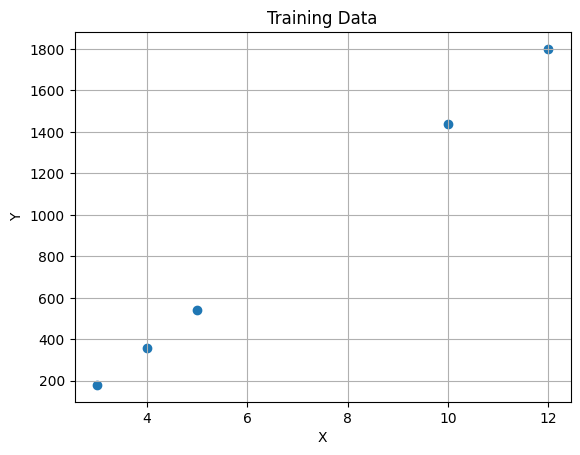

In [10]:
import matplotlib.pyplot as plt

plt.scatter(X_train, Y_train)
plt.title("Training Data")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

## Initial Predictions

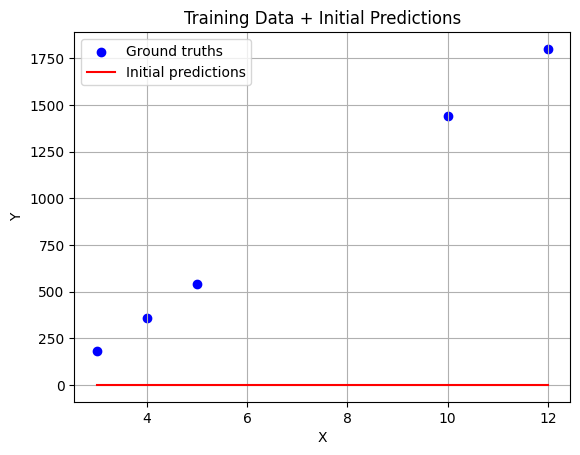

In [11]:
w1 = 0
w0 = 0

y_pred = w1 * X_train + w0

plt.scatter(X_train, Y_train, color='blue', label='Ground truths')

plt.plot(X_train, y_pred, color='red', label='Initial predictions')

plt.title("Training Data + Initial Predictions")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
learning_rate = 0.001
epochs = 1000

w1 = 0
w0 = 0

error_history = []

for epoch in range(epochs):

    total_epoch_error = 0

    for i in range(len(X_train)): # x_i, y_i
        x_sample = X_train[i]
        y_actual = Y_train[i]

        y_pred = w1 * x_sample + w0

        delta_w1 = -(y_actual - y_pred) * x_sample
        delta_w0 = -(y_actual - y_pred)

        w1 = w1 - learning_rate * delta_w1
        w0 = w0 - learning_rate * delta_w0

        total_epoch_error += (y_actual - y_pred)**2

    error_history.append(total_epoch_error / len(X_train))

print(f"w1 = {w1:.4f}")
print(f"w0 = {w0:.4f}")

print(f"\nPredicted y = {w1:.4f}*X + {w0:.4f}")


w1 = 165.6981
w0 = -231.2357

Predicted y = 165.6981*X + -231.2357


In [13]:
from operator import mul

xss = np.array([
    [1, 3],
    [1, 4],
    [1, 5],
    [1, 10],
    [1, 12],
])
ys = np.array([
    180,
    360,
    540,
    1440,
    1800,
])

def h(ws, xs):
    return sum(map(mul, ws, xs))
    
ws = [0, 0]
alpha = 0.006
epochs = 0
error_history = []
while True:
    any_update = False
    for i, w in enumerate(ws):
        dw = 0
        for xs, y in zip(xss, ys):
            dw += (h(ws, xs) - y) * xs[i]
        
        w_p = w - alpha*dw
        any_update = any_update or w_p != w
        ws[i] = w_p

    if not any_update:
        break

    epochs += 1
    # lms = sum(map(lambda xy: (h(xy[0]) - xy[1])**2, zip(X_train, Y_train)))
    # error_history.append(lms)

w0, w1 = ws
print(f'{w0:.4}, {w1:.4}, {epochs}')

-360.0, 180.0, 4928


In [14]:
import numpy as np

w0, w1 = 0, 0

xs = X_train
ys = Y_train
m  = len(xs)

def h(x):
    return w0 + w1*x

alpha = 0.005
epochs = 0
error_history = []
while True:
    dw0 = 0
    for i in range(m):
        x, y = xs[i], ys[i]
        dw0 += h(x) - y

    dw1 = 0
    for i in range(m):
        x, y = xs[i], ys[i]
        dw1 += (h(x) - y) * x

    if w0 == w0 - alpha*dw0 and w1 == w1 - alpha*dw1:
        break

    loss = sum((h(xs[i]) - ys[i])**2 for i in range(m)) / m
    error_history.append(loss)

    w0 = w0 - alpha*dw0
    w1 = w1 - alpha*dw1
    epochs += 1


print(f'{w0:0.4f} {w1:0.4f}, {epochs}')


-360.0000 180.0000, 6006


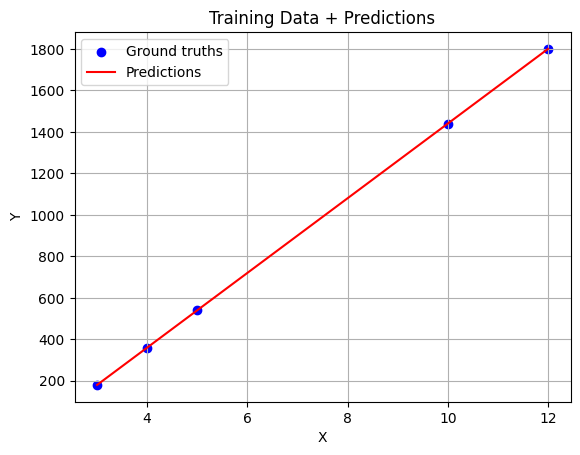

In [15]:
y_pred = w1 * X_train + w0

plt.scatter(X_train, Y_train, color='blue', label='Ground truths')

plt.plot(X_train, y_pred, color='red', label='Predictions')

plt.title("Training Data + Predictions")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()

## Error Over Time

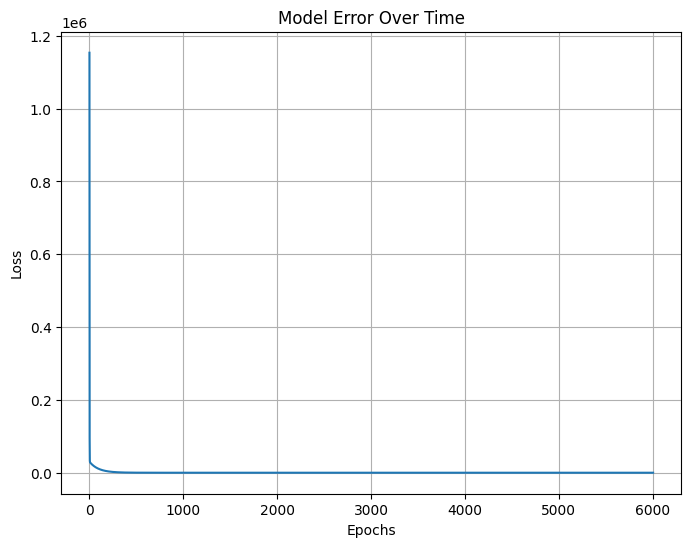

In [16]:
plt.figure(figsize=(8,6))
plt.plot(range(epochs), error_history)

plt.title("Model Error Over Time")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.grid(True)
plt.show()